In [2]:
from behavior_analysis.experiment import BehaviorExperiment
import pandas as pd
# Open experiment
experiment = BehaviorExperiment.open(r"C:\Users\manyung.ng\Documents\behaviour_analysis\behavior_analysis_tracking\mafaa_analysis")
print(experiment)
# Open video and bout info
video_info = pd.read_csv(experiment.directory.joinpath('video_data.csv'), dtype={'ID': str, 'code': str})
bouts_df = pd.read_csv(experiment.subdirs["analysis"].joinpath('bouts.csv'),
                        dtype={'ID': str, 'code': str})

name: mafaa_analysis
date: 2025-06-30
animal_data: fish_data.csv
video_data: video_data.csv
mask_data: mask_data.csv
bout_detection: {'threshold': 0.03, 'winsize': 0.07}



In [3]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import squareform
from pathlib import Path
import numpy as np
from behavior_analysis.analysis.csv import import_csvs
import os

In [4]:
# plotting with seaborn
import seaborn as sns
# set figure size
sns.set_theme(rc={"figure.figsize": (15,5)})

In [5]:
kinematics = import_csvs(experiment.subdirs['kinematics'], index_levels=(1,0), level_names=("ID", 'code', "frame"))
retained_columns = ['ID', 'code', 'frame', 'speed', 'angular_velocity']
kinematics = kinematics.reset_index().get(retained_columns)
kinematics

Opening 96 csv files...
#################### 100%
done!
DataFrame has shape: (3601770, 57).
Index levels: ('ID', 'code', 'frame').



,ID,code,frame,speed,angular_velocity
0,2025061201,2025061201134603.404,0,0.000000,0.000000
1,2025061201,2025061201134603.404,1,0.000000,0.000000
2,2025061201,2025061201134603.404,2,0.000000,0.000000
3,2025061201,2025061201134603.404,3,0.000000,0.000000
4,2025061201,2025061201134603.404,4,0.000000,0.000000
...,...,...,...,...,...
3601765,2025061208,2025061208192132.138,37511,22.934099,1.394500
3601766,2025061208,2025061208192132.138,37512,187.256930,0.031255
3601767,2025061208,2025061208192132.138,37513,753.601108,0.000000
3601768,2025061208,2025061208192132.138,37514,741.935163,-1.337896


#### plot angular velocity over time in a session

KeyboardInterrupt: 

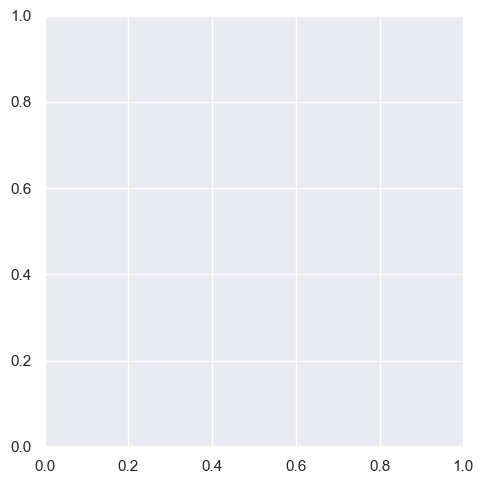

In [ ]:
# plot angular velocity over time in a session
# vertical gray dash line is roughly when the paramecia is added (5 min after recording started)
# horizontal black dash line is the convergence threshold for that fish
sub_df = kinematics[kinematics['ID'] == '2025061204'].reset_index() # change ID number here
sns.displot(data=sub_df, x=sub_df.index, y="speed", legend='auto', kind='kde')
plt.axhline(y=sub_df[sub_df['ID'] == '2025061204'].angular_velocity.mean(), linestyle='--', c='black') # change ID number here
plt.axvline(x=250*150*2, linestyle='--', c='gray') # rough timepoint of when paramecia were introduced